In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (precision_recall_curve,average_precision_score,f1_score,precision_score,recall_score)

In [14]:
df = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\model_ready_dataset.csv")

df.head()

,HDF,OSF,PWF,TWF,rpm_torque_interaction,Rotational speed [rpm],load_stress,Torque [Nm],load_density,Tool wear [min],temperature_ratio,tool_wear_mean_10,temperature_difference,air_temp_mean_10,UDI,Machine failure
0,0,0,0,0,71177.0,1306,29.7025,54.5,0.545,50,1.034806,36.8,10.4,298.60,19,0
1,0,0,0,0,53040.0,1632,10.5625,32.5,0.325,55,1.034794,40.2,10.4,298.64,20,0
2,0,0,0,0,58712.5,1375,18.2329,42.7,0.427,58,1.034794,43.6,10.4,298.69,21,0
3,0,0,0,0,64960.0,1450,20.0704,44.8,0.448,63,1.035141,47.0,10.5,298.71,22,0
4,0,0,0,0,48536.7,1581,9.4249,30.7,0.307,65,1.034794,50.1,10.4,298.74,23,0


In [15]:
X = df.drop("Machine failure", axis=1)

y = df["Machine failure"]

X.columns = (
    X.columns
    .str.replace("[","",regex=False)
    .str.replace("]","",regex=False)
    .str.replace("{","",regex=False)
    .str.replace("}","",regex=False)
    .str.replace(":","",regex=False)
    .str.replace(",","",regex=False)
)

leak_columns = [
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = X.drop(
    columns=[
        col for col in leak_columns
        if col in X.columns
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
model = joblib.load(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\models\final_lightgbm_model.pkl")

In [19]:
y_prob = model.predict_proba(X_test)[:,1]

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)

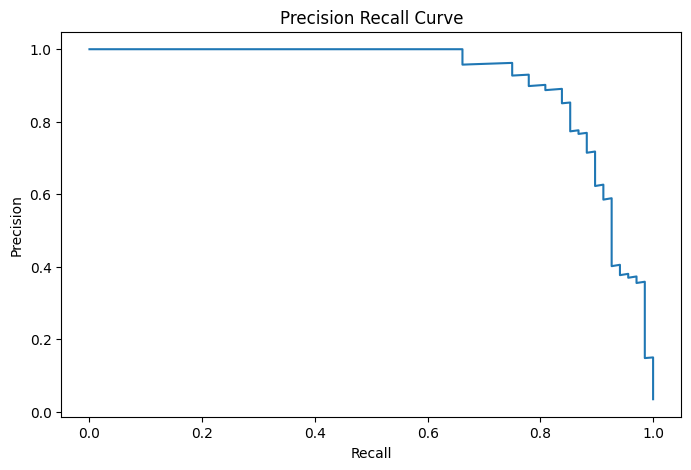

In [21]:
plt.figure(figsize=(8,5))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [22]:
ap_score = average_precision_score(y_test,y_prob)

ap_score

np.float64(0.9146858315995022)

In [23]:
threshold_results = []

for threshold in np.arange(0.1,0.9,0.05):
    pred = (y_prob>=threshold).astype(int)
    threshold_results.append({
        "Threshold":threshold,
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred)
    })

In [24]:
threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.508065,0.926471,0.656250
1,0.15,0.577982,0.926471,0.711864
2,0.20,0.601942,0.911765,0.725146
3,0.25,0.607843,0.911765,0.729412
4,0.30,0.628866,0.897059,0.739394
5,0.35,0.655914,0.897059,0.757764
6,0.40,0.677778,0.897059,0.772152
7,0.45,0.685393,0.897059,0.777070
8,0.50,0.701149,0.897059,0.787097
9,0.55,0.731707,0.882353,0.800000


In [26]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

best_row

Threshold    0.800000
Precision    0.852941
Recall       0.852941
F1           0.852941
Name: 14, dtype: float64

In [27]:
threshold_df.to_csv(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\threshold_tuning_results.csv",index=False)